In [21]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [23]:
df = pd.read_csv("C:\\Users\\sampada\\machine-learning-journey\\Transformation\\train_titanic.csv",usecols=['Age','Fare','Survived'])

In [25]:
df.head()


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [27]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [29]:
df['Age']=df['Age'].fillna(df['Age'].mean())


In [55]:
X_train,X_test,y_train,y_test=train_test_split(df.iloc[:,1:3],df.iloc[:,0],test_size=0.2,random_state=42)

C:\Users\sampada\AppData\Local\Temp\ipykernel_8724\2888751792.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


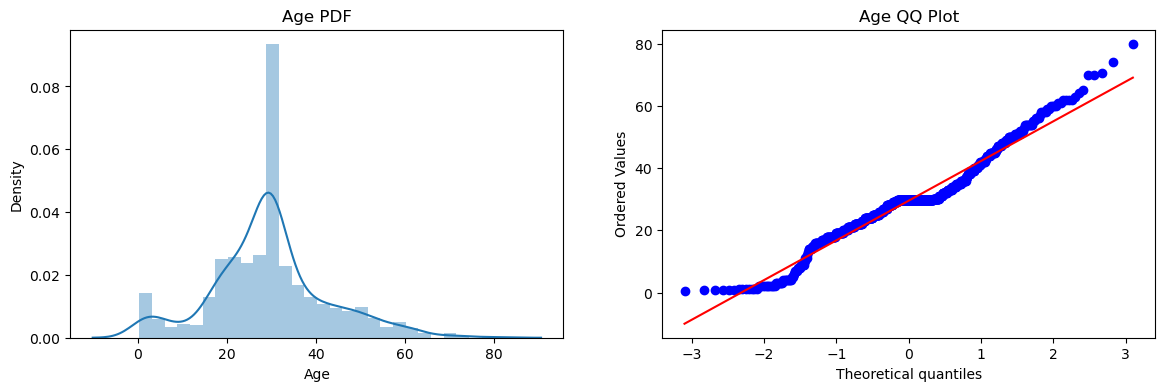

In [37]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

C:\Users\sampada\AppData\Local\Temp\ipykernel_8724\2981780686.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


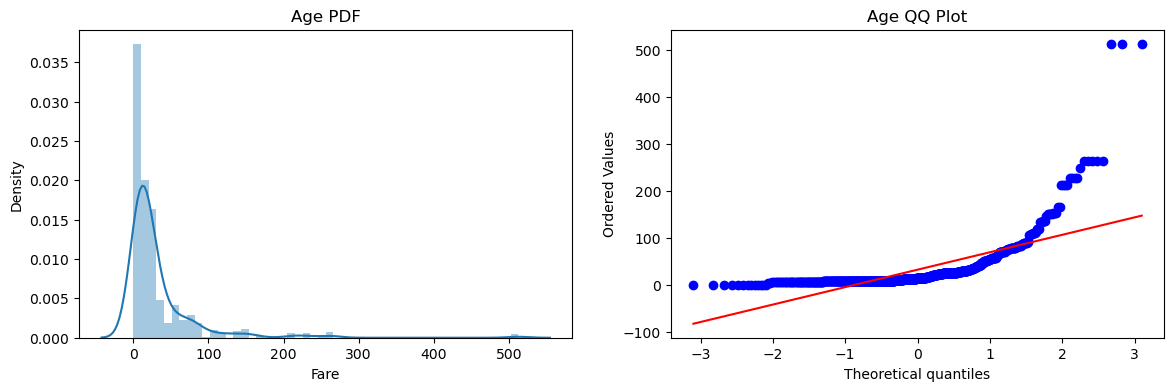

In [39]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [45]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print('Accuracy LR:',accuracy_score(y_test,y_pred))
print('Accuracy DT:',accuracy_score(y_test,y_pred1))
      



Accuracy LR: 0.6480446927374302
Accuracy DT: 0.6703910614525139


In [49]:
trf=FunctionTransformer(func=np.log1p)  #log1p add 1 so value never become zero

In [51]:
X_train_transform=trf.fit_transform(X_train)
X_test_transform=trf.transform(X_test)

clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(X_train_transform,y_train)
clf2.fit(X_train_transform,y_train)

y_pred = clf.predict(X_test_transform)
y_pred1 = clf2.predict(X_test_transform)

print('Accuracy LR:',accuracy_score(y_test,y_pred))
print('Accuracy DT:',accuracy_score(y_test,y_pred1))
      

Accuracy LR: 0.6815642458100558
Accuracy DT: 0.6759776536312849


In [61]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()
    

Accuracy 0.6589013732833957


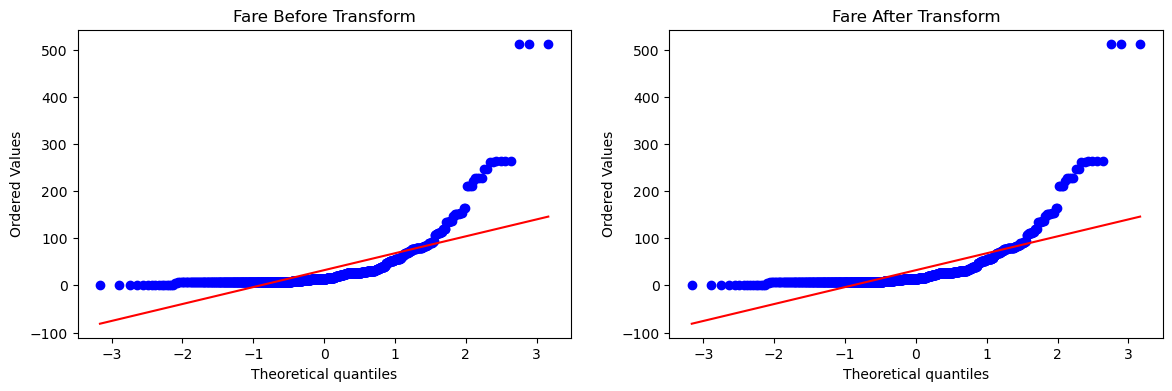

In [63]:
apply_transform(lambda X:X)

Accuracy 0.6431335830212235


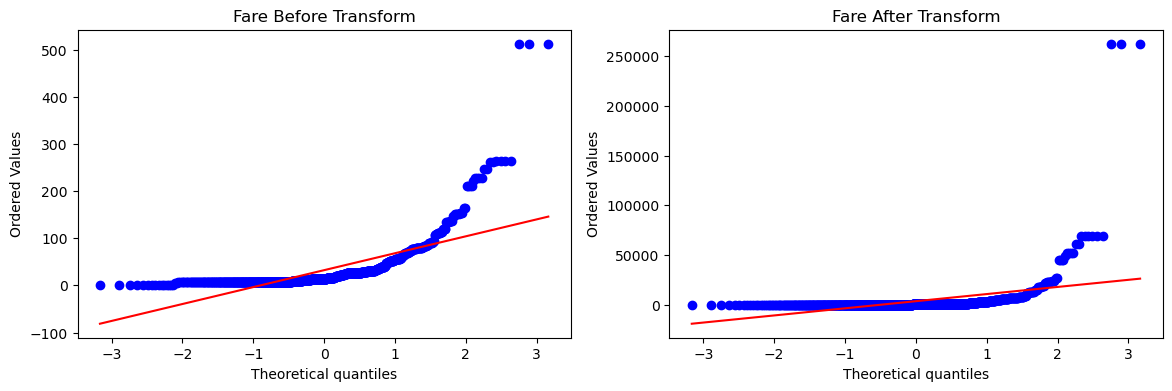

In [65]:
apply_transform(lambda X:X**2) # sqr transform

Accuracy 0.6589013732833957


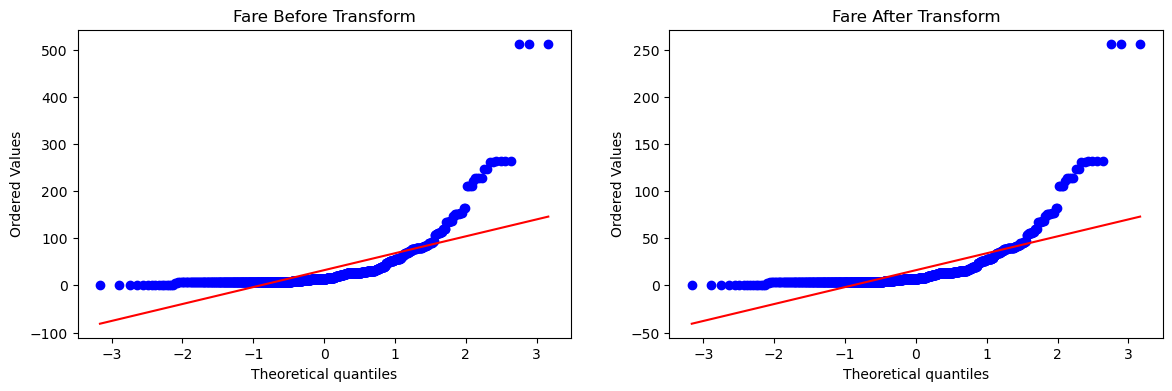

In [67]:
apply_transform(lambda X:X**1/2)